In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Load and Check Data

In [2]:
train = pd.read_csv("/kaggle/input/titanic/train.csv")
test = pd.read_csv("/kaggle/input/titanic/test.csv")
all_data = pd.concat([train,test], sort=False).reset_index(drop=True)
test_PassengerId = test["PassengerId"]
train_len = len(train)

In [3]:
print('Number of Training Examples = {}'.format(train.shape[0]))
print('Number of Test Examples = {}\n'.format(test.shape[0]))

print('"train" Shape = {}'.format(train.shape))
print('"test" Shape = {}'.format(test.shape))
print('"all_data" Shape = {}\n'.format(all_data.shape))

print(all_data.columns)

Number of Training Examples = 891
Number of Test Examples = 418

"train" Shape = (891, 12)
"test" Shape = (418, 11)
"all_data" Shape = (1309, 12)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [4]:
all_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
all_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1308,1309,NaN,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [6]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


## Variable Description

1. PassengerId: unique id number to each passenger
1. Survived: passenger survive(1) or died(0)
1. Pclass: passenger class
1. Name
1. Sex
1. Age
1. SibSp: number of siblings/spouses
1. Parch: number of parents/children
1. Ticket: ticket number
1. Fare: amount of money spent on ticket
1. Cabin: cabin category
1. Embarked: port where passenger embarked (C = Cherbourg, Q = Queenstown, S = Southampton)

### Categorical Features

In [7]:
# Selecting categorical data for univariate analysis:

cats = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

def plotFrequency(cats):
    
    fig, axes = plt.subplots(3, 2, figsize=(20,25))
    axes = axes.flatten()

    for ax, cat in zip(axes, cats):
        if cat == 'Survived':
            total = float(len(train[cat]))
        else:
            total = float(len(all_data[cat]))
        sns.countplot(all_data[cat], palette='plasma', ax=ax)
        
        
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x() + p.get_width() / 2.,
                    height + 10,
                    '{:1.2f}%'.format((height / total) * 100),
                    ha="center")

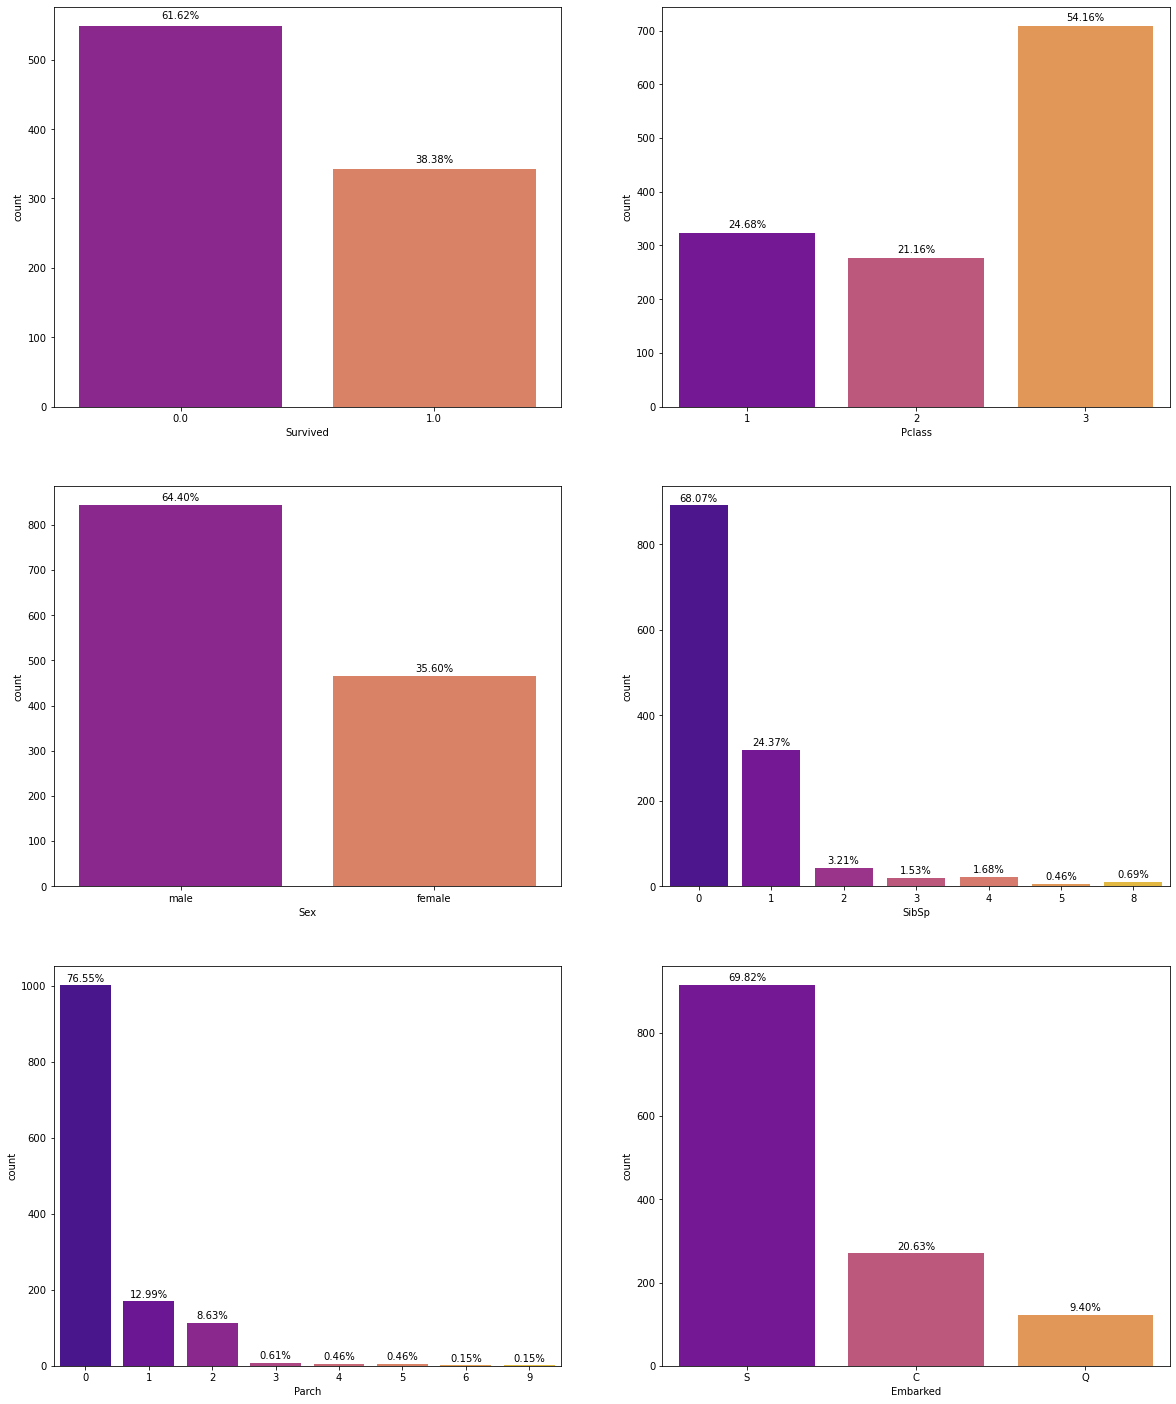

In [8]:
plotFrequency(cats)

In [9]:
# Relationship of categorical data with the target variable

def plotsurvival(cats, data):
    
    fig, axes = plt.subplots(3, 2, figsize=(20, 20))
    axes = axes.flatten()

    for ax, cat in zip(axes, cats):
        if cat == 'Survived':
            sns.countplot(train[cat], palette='plasma', ax=ax)

        else:

            sns.countplot(x=cat,
                          data=data,
                          hue='Survived',
                          palette='plasma',
                          ax=ax)
            ax.legend(title='Survived?',
                      loc='upper right',
                      labels=['No', 'Yes'])

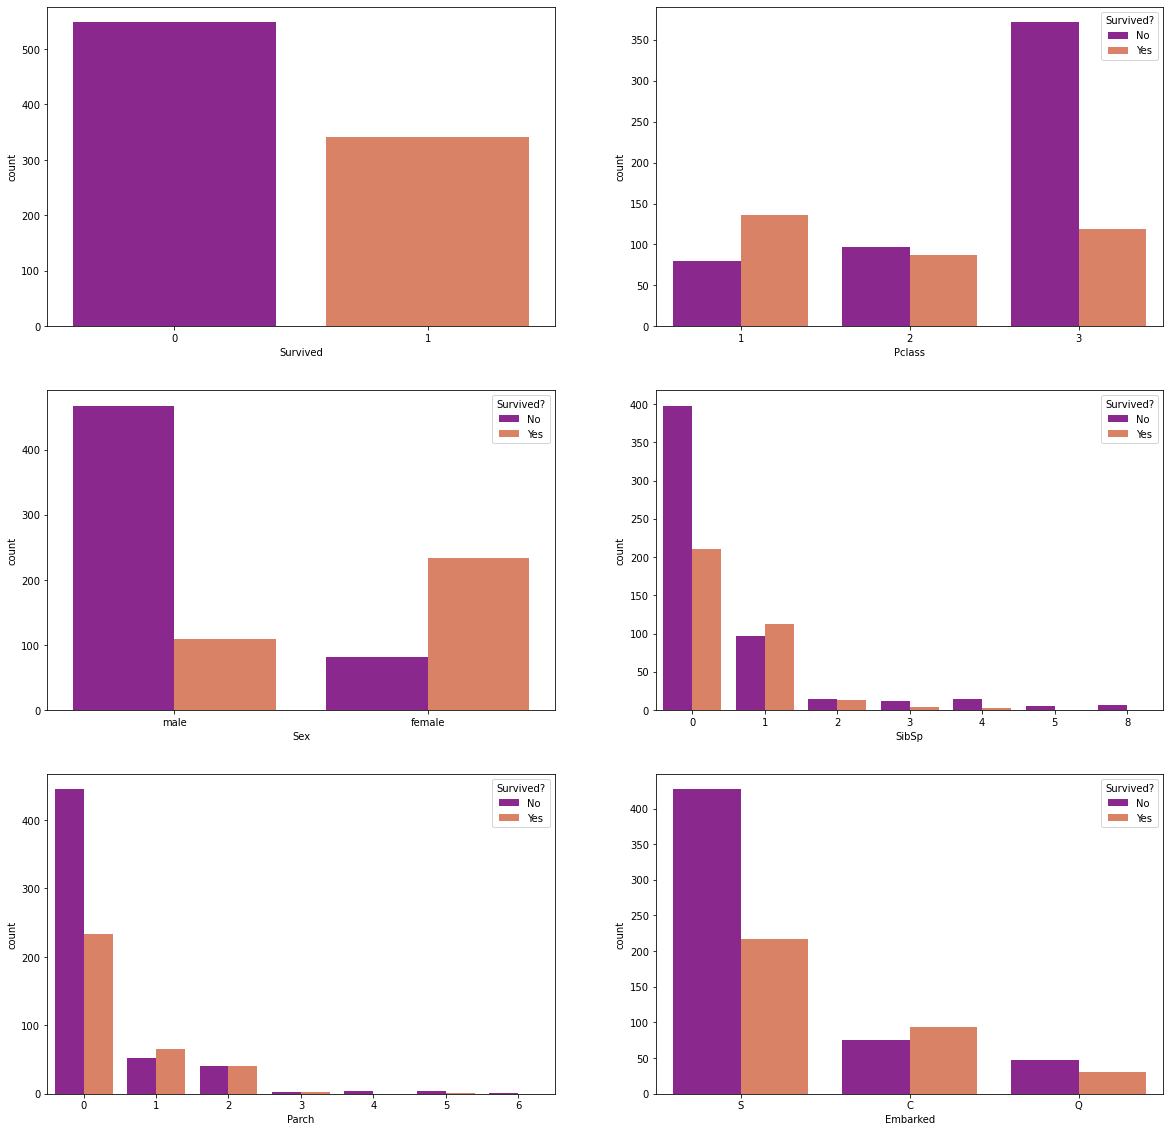

In [10]:
plotsurvival(cats, train)

### Numerical Features

In [11]:
# Selecting numerical data for univariate analysis:

def histPlot(num):
    sns.histplot(data = all_data, x = num, bins = 50)
    print("{} distribution with hist:".format(num))
    plt.show()


Age distribution with hist:


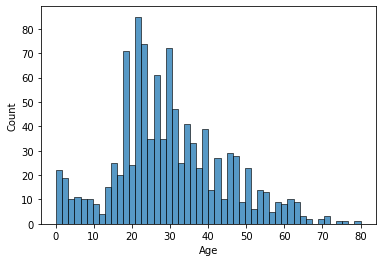

Fare distribution with hist:


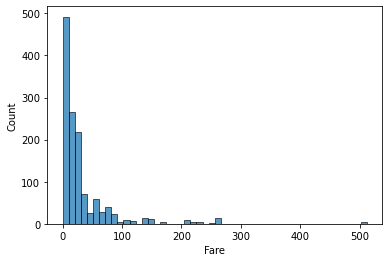

In [12]:
nums = ["Age","Fare"]

for i in nums:
    histPlot(i)

In [13]:
# Relationship of numerical data with the target variable

def histPlot2(num):
    g = sns.FacetGrid(all_data, col = "Survived")
    g.map(sns.histplot, num, kde = True, stat = "density")
    plt.show()

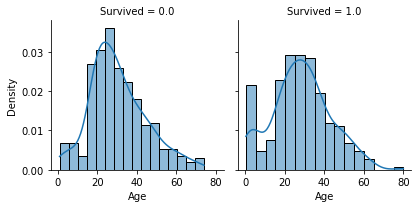

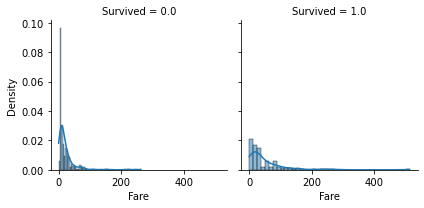

In [14]:
nums = ["Age","Fare"]

for i in nums:
    histPlot2(i)

## Missing Values

In [15]:
def display_missing(df):    
    for col in df.columns.tolist():          
        print('{} column missing values: {}'.format(col, df[col].isnull().sum()))
    print('\n')
    
display_missing(all_data)

PassengerId column missing values: 0
Survived column missing values: 418
Pclass column missing values: 0
Name column missing values: 0
Sex column missing values: 0
Age column missing values: 263
SibSp column missing values: 0
Parch column missing values: 0
Ticket column missing values: 0
Fare column missing values: 1
Cabin column missing values: 1014
Embarked column missing values: 2




#### let's visualize the missing data

**1-with missingno library**

In [16]:
!pip install missingno

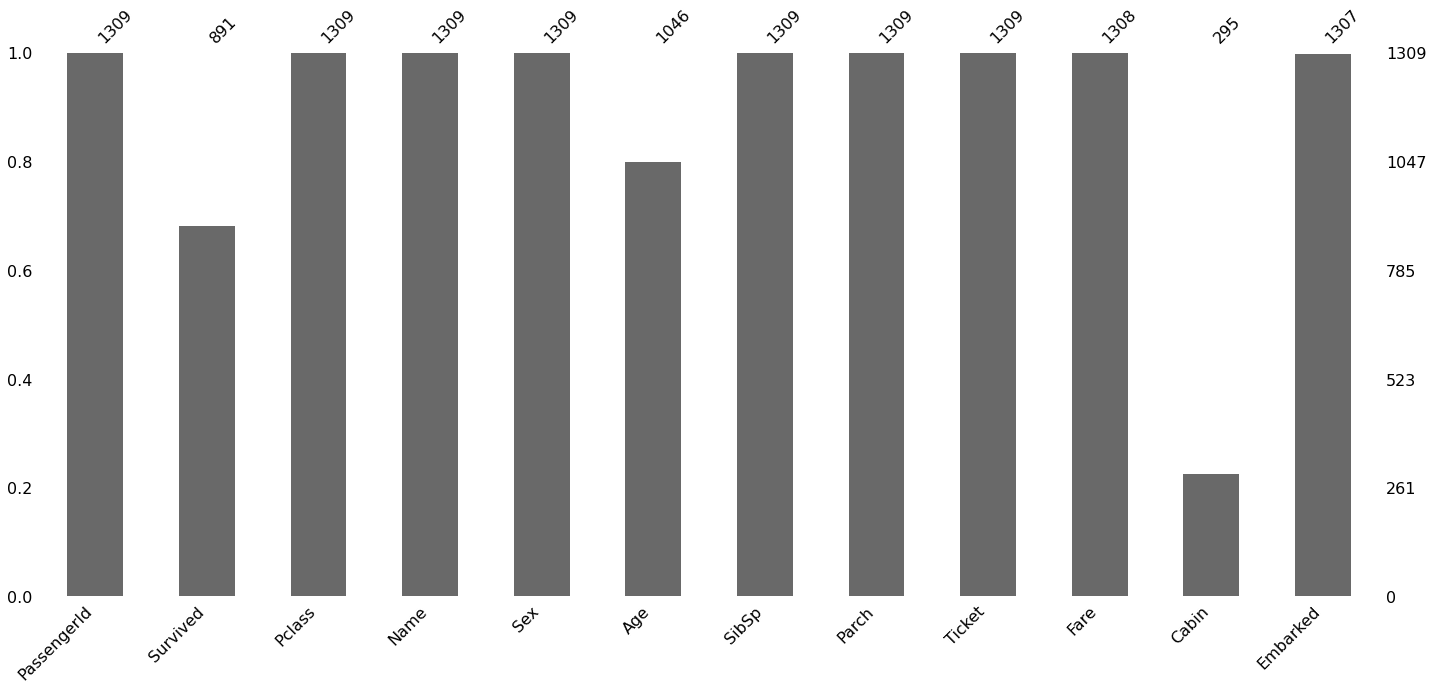

In [17]:
import missingno as msno 

msno.bar(all_data);

# alternative visuals: ==>  msno.matrix(all_data)       
#                      ==>  msno.heatmap(all_data)

**2-with seaborn**

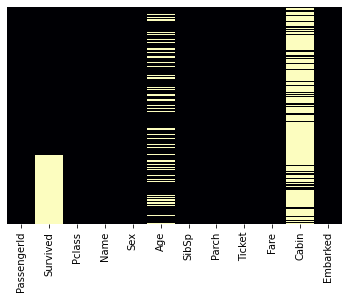

In [18]:
sns.heatmap(all_data.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='magma');

It is convenient to work on concatenated training and test set while dealing with missing values, otherwise filled data may overfit to training or test set samples. As seen above, the number of missing values in Age, Embarked and Fare are smaller compared to total sample, but roughly 80% of the Cabin is missing. Missing values in Age, Embarked and Fare can be filled but that wouldn't work for Cabin.

### Age missing values

In [19]:
all_data_corr = all_data.corr().abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()
all_data_corr[all_data_corr['level_0'] == 'Age']

,level_0,level_1,0
5,Age,Age,1.000000
9,Age,Pclass,0.408106
18,Age,SibSp,0.243699
22,Age,Fare,0.178740
25,Age,Parch,0.150917
30,Age,Survived,0.077221
42,Age,PassengerId,0.028814


In [20]:
# Median age of Pclass groups is the best choice because of its high correlation

age_by_pclass_sex = all_data.groupby(['Sex', 'Pclass']).median()['Age']

for pclass in range(1, 4):
    for sex in ['female', 'male']:
        print('Median age of Pclass {} {}s: {}'.format(pclass, sex, age_by_pclass_sex[sex][pclass]))
print('Median age of all passengers: {}'.format(all_data['Age'].median()))

# Filling the missing values in Age with the medians of Sex and Pclass groups
all_data['Age'] = all_data.groupby(['Sex', 'Pclass'])['Age'].apply(lambda x: x.fillna(x.median()))

Median age of Pclass 1 females: 36.0
Median age of Pclass 1 males: 42.0
Median age of Pclass 2 females: 28.0
Median age of Pclass 2 males: 29.5
Median age of Pclass 3 females: 22.0
Median age of Pclass 3 males: 25.0
Median age of all passengers: 28.0


In [21]:
all_data["Age"].isnull().sum()

0

### Embarked missing values

In [22]:
all_data[all_data['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


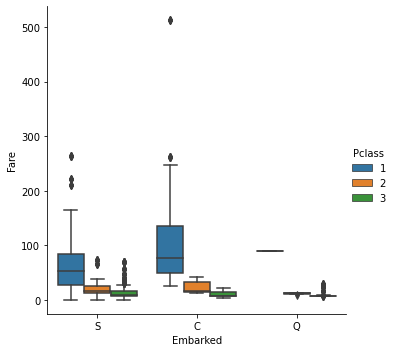

In [23]:
sns.catplot(x = "Embarked", y = "Fare", hue = "Pclass", data = all_data, kind = "box")
plt.show()

Embarked is a categorical feature and there are only 2 missing values in whole data set. Both of those passengers are female, upper class and they have the same ticket number. This means that they know each other and embarked from the same port together. The mode Embarked value for an upper class female passenger is C (Cherbourg), but this doesn't necessarily mean that they embarked from that port.

In [24]:
# Filling the missing values in Embarked with C
all_data['Embarked'] = all_data['Embarked'].fillna('C')

In [25]:
all_data["Embarked"].isnull().sum()

0

### Fare missing values

In [26]:
all_data[all_data['Fare'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [27]:
all_data_corr = all_data.corr().abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()
all_data_corr[all_data_corr['level_0'] == 'Fare']

,level_0,level_1,0
6,Fare,Fare,1.000000
7,Fare,Pclass,0.558629
15,Fare,Survived,0.257307
17,Fare,Parch,0.221539
21,Fare,Age,0.200039
23,Fare,SibSp,0.160238
39,Fare,PassengerId,0.031428


There is only one passenger with missing Fare value. We can assume that Fare is related to family size (Parch and SibSp) and Pclass features. Median Fare value of a male with a third class ticket and no family is a logical choice to fill the missing value.

In [28]:
median_fare = all_data.groupby(['Pclass', 'Parch', 'SibSp']).Fare.median()[3][0][0]
# Filling the missing value in Fare with the median Fare of 3rd class alone passenger
all_data['Fare'] = all_data['Fare'].fillna(median_fare)

In [29]:
all_data["Fare"].isnull().sum()

0

# Visualization

In [30]:
all_data.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.038354,0.020478,-0.055224,0.008942,0.031026
Survived,-0.005007,1.000000,-0.338481,-0.058635,-0.035322,0.081629,0.257307
Pclass,-0.038354,-0.338481,1.000000,-0.451983,0.060832,0.018322,-0.558742
Age,0.020478,-0.058635,-0.451983,1.000000,-0.204025,-0.134239,0.198704
SibSp,-0.055224,-0.035322,0.060832,-0.204025,1.000000,0.373587,0.160389
Parch,0.008942,0.081629,0.018322,-0.134239,0.373587,1.000000,0.221669
Fare,0.031026,0.257307,-0.558742,0.198704,0.160389,0.221669,1.000000


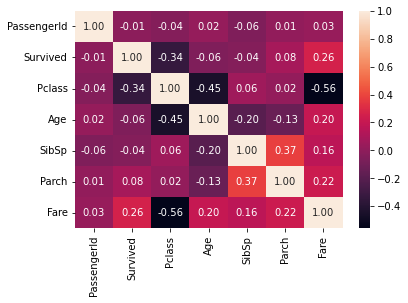

In [31]:
sns.heatmap(all_data.corr(), annot = True, fmt = ".2f")
plt.show()

### SibSp -- Survived

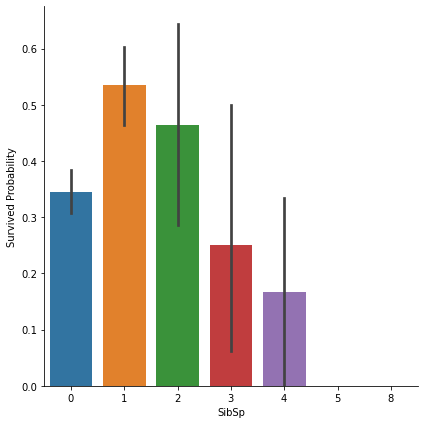

In [32]:
sns.catplot(x = "SibSp", y = "Survived", data = all_data, kind = "bar", height = 6)
plt.ylabel("Survived Probability")              
plt.show()

Having a lot of SibSp have less chance to survive.

if sibsp == 0 or 1 or 2, passenger has more chance to survive

we can consider a new feature describing these categories.

### Parch -- Survived

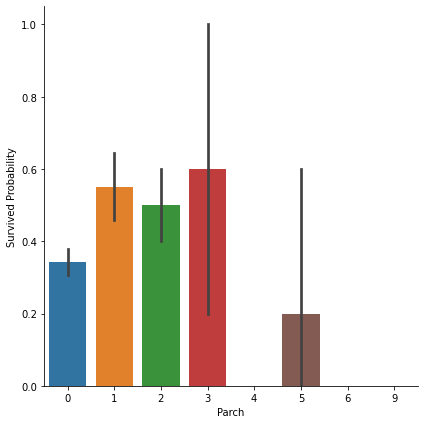

In [33]:
g = sns.catplot(x = "Parch", y = "Survived", kind = "bar", data = all_data, height = 6)   
g.set_ylabels("Survived Probability")              
plt.show()

Sibsp and parch can be used for new feature extraction with th = 3

small familes have more chance to survive.

there is a std in survival of passenger with parch = 3

### Pclass -- Survived

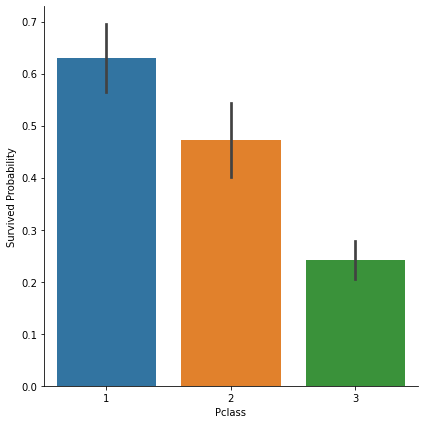

In [34]:
g = sns.catplot(x = "Pclass", y = "Survived", data = all_data, kind = "bar", height = 6)
g.set_ylabels("Survived Probability")
plt.show()

### Age -- Survived

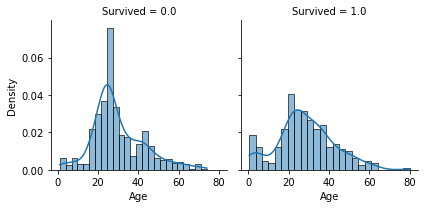

In [35]:
g = sns.FacetGrid(all_data, col = "Survived")
g.map(sns.histplot, "Age", bins = 25, kde = True, stat = "density")
plt.show()

### Pclass -- Survived -- Age

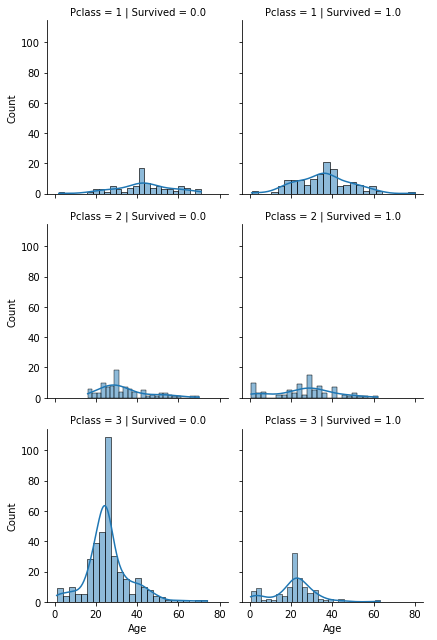

In [36]:
g = sns.FacetGrid(all_data, col = "Survived", row = "Pclass", height = 3)
g.map(sns.histplot, "Age", bins = 25, kde = True)                                           
g.add_legend()
plt.show()

### Embarked -- Sex -- Fare -- Survived

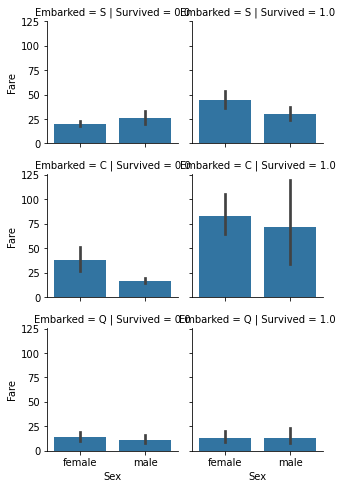

In [37]:
g = sns.FacetGrid(all_data, row = "Embarked", col = "Survived", height = 2.3)
g.map(sns.barplot, "Sex", "Fare")
g.add_legend()
plt.show()

# Feature Engineering 

### Name/Title

In [38]:
all_data.Name.head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

In [39]:
# Get Title from Name
data_title = [i.split(",")[1].split(".")[0].strip() for i in all_data["Name"]]
all_data["Title"] = pd.Series(data_title)
all_data["Title"].head(10)

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
5        Mr
6        Mr
7    Master
8       Mrs
9       Mrs
Name: Title, dtype: object

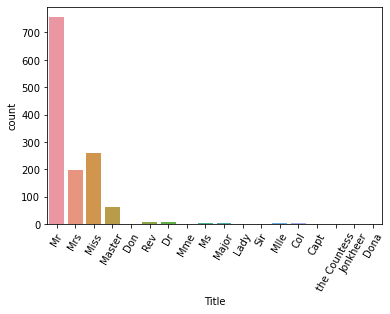

In [40]:
sns.countplot(x="Title", data = all_data)
plt.xticks(rotation = 60)
plt.show()

In [41]:
all_data['Title'] = all_data['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Lady', 'Jonkheer', 'Don', 'Capt', 'the Countess',
                                             'Sir', 'Dona'], 'Rare')
all_data['Title'] = all_data['Title'].replace(['Mlle', 'Ms'], 'Miss')
all_data['Title'] = all_data['Title'].replace('Mme', 'Mrs')

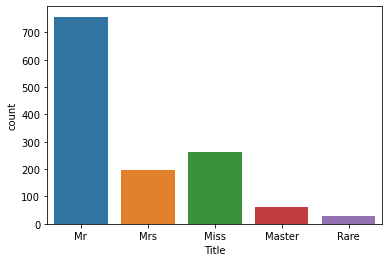

In [42]:
sns.countplot(all_data['Title']);

In [43]:
# Mean of survival by name title

all_data[['Title', 'Survived']].groupby(['Title'], as_index = False).mean().sort_values(by = 'Survived', ascending = False)

,Title,Survived
3,Mrs,0.793651
1,Miss,0.702703
0,Master,0.575000
4,Rare,0.347826
2,Mr,0.156673


Text(0.5, 1.0, 'Mean of survival by Title')

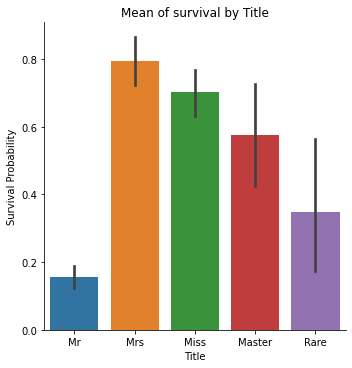

In [44]:
sns.factorplot(x = 'Title', y = 'Survived', data = all_data, kind = 'bar')
plt.ylabel('Survival Probability')
plt.title('Mean of survival by Title')

In [45]:
all_data.drop(labels = ["Name"], axis = 1, inplace = True)

In [46]:
# One-Hot Encoder 

all_data = pd.get_dummies(all_data,columns=["Title"])

In [47]:
all_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0.0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,1,0,0
1,2,1.0,1,female,38.0,1,0,PC 17599,71.2833,C85,C,0,0,0,1,0
2,3,1.0,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,0
3,4,1.0,1,female,35.0,1,0,113803,53.1000,C123,S,0,0,0,1,0
4,5,0.0,3,male,35.0,0,0,373450,8.0500,NaN,S,0,0,1,0,0


### Family Size

In [48]:
all_data["Fsize"] = all_data["SibSp"] + all_data["Parch"] + 1

In [49]:
all_data.Fsize.value_counts()

1     790
2     235
3     159
4      43
6      25
5      22
7      16
11     11
8       8
Name: Fsize, dtype: int64

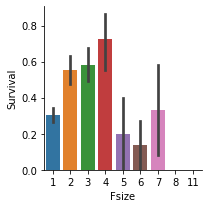

In [50]:
g = sns.catplot(x = "Fsize", y = "Survived", data = all_data, kind = "bar", height = 3)
g.set_ylabels("Survival")
plt.show()

In [51]:
all_data['Single'] = all_data['Fsize'].map(lambda s: 1 if s == 1 else 0)
all_data['SmallF'] = all_data['Fsize'].map(lambda s: 1 if  s == 2  else 0)
all_data['MedF'] = all_data['Fsize'].map(lambda s: 1 if 3 <= s <= 4 else 0)
all_data['LargeF'] = all_data['Fsize'].map(lambda s: 1 if s >= 5 else 0)

In [52]:
all_data.head(5)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Fsize,Single,SmallF,MedF,LargeF
0,1,0.0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,...,0,0,1,0,0,2,0,1,0,0
1,2,1.0,1,female,38.0,1,0,PC 17599,71.2833,C85,...,0,0,0,1,0,2,0,1,0,0
2,3,1.0,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,...,0,1,0,0,0,1,1,0,0,0
3,4,1.0,1,female,35.0,1,0,113803,53.1000,C123,...,0,0,0,1,0,2,0,1,0,0
4,5,0.0,3,male,35.0,0,0,373450,8.0500,NaN,...,0,0,1,0,0,1,1,0,0,0


In [53]:
all_data.drop(labels = ["Fsize"], axis = 1, inplace = True)

### Embarked

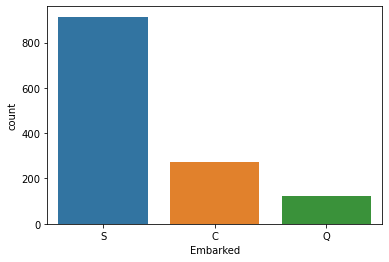

In [54]:
sns.countplot(x = "Embarked", data = all_data)
plt.show()

In [55]:
all_data = pd.get_dummies(all_data, columns=["Embarked"])

### Pclass

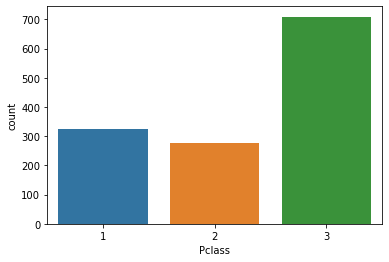

In [56]:
sns.countplot(x = "Pclass", data = all_data)
plt.show()

In [57]:
all_data["Pclass"] = all_data["Pclass"].astype("category")

In [58]:
all_data = pd.get_dummies(all_data, columns= ["Pclass"])
all_data.head()

,PassengerId,Survived,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Title_Master,...,Single,SmallF,MedF,LargeF,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,1,0.0,male,22.0,1,0,A/5 21171,7.2500,NaN,0,...,0,1,0,0,0,0,1,0,0,1
1,2,1.0,female,38.0,1,0,PC 17599,71.2833,C85,0,...,0,1,0,0,1,0,0,1,0,0
2,3,1.0,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,...,1,0,0,0,0,0,1,0,0,1
3,4,1.0,female,35.0,1,0,113803,53.1000,C123,0,...,0,1,0,0,0,0,1,1,0,0
4,5,0.0,male,35.0,0,0,373450,8.0500,NaN,0,...,1,0,0,0,0,0,1,0,0,1


### Sex

In [59]:
all_data["Sex"] = all_data["Sex"].astype("category")
all_data = pd.get_dummies(all_data, columns=["Sex"])
all_data.head()

,PassengerId,Survived,Age,SibSp,Parch,Ticket,Fare,Cabin,Title_Master,Title_Miss,...,MedF,LargeF,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male
0,1,0.0,22.0,1,0,A/5 21171,7.2500,NaN,0,0,...,0,0,0,0,1,0,0,1,0,1
1,2,1.0,38.0,1,0,PC 17599,71.2833,C85,0,0,...,0,0,1,0,0,1,0,0,1,0
2,3,1.0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,...,0,0,0,0,1,0,0,1,1,0
3,4,1.0,35.0,1,0,113803,53.1000,C123,0,0,...,0,0,0,0,1,1,0,0,1,0
4,5,0.0,35.0,0,0,373450,8.0500,NaN,0,0,...,0,0,0,0,1,0,0,1,0,1


### Ticket

In [60]:
tickets = []
for i in list(all_data.Ticket):
    if not i.isdigit():                      
        tickets.append(i.replace(".","").replace("/","").strip().split(" ")[0])
    else:
        tickets.append("x")
        
all_data["Ticket"] = tickets

In [61]:
all_data["Ticket"].head(6)

0        A5
1        PC
2    STONO2
3         x
4         x
5         x
Name: Ticket, dtype: object

In [62]:
all_data["Ticket"].unique()

array(['A5', 'PC', 'STONO2', 'x', 'PP', 'CA', 'SCParis', 'SCA4', 'A4',
       'SP', 'SOC', 'WC', 'SOTONOQ', 'WEP', 'STONO', 'C', 'SCPARIS',
       'SOP', 'Fa', 'LINE', 'FCC', 'SWPP', 'SCOW', 'PPP', 'SC', 'SCAH',
       'AS', 'SOPP', 'FC', 'SOTONO2', 'CASOTON', 'SCA3', 'STONOQ', 'AQ4',
       'A', 'LP', 'AQ3'], dtype=object)

In [63]:
all_data = pd.get_dummies(all_data, columns= ["Ticket"], prefix = "T")
all_data.head(5)

,PassengerId,Survived,Age,SibSp,Parch,Fare,Cabin,Title_Master,Title_Miss,Title_Mr,...,T_SOTONO2,T_SOTONOQ,T_SP,T_STONO,T_STONO2,T_STONOQ,T_SWPP,T_WC,T_WEP,T_x
0,1,0.0,22.0,1,0,7.2500,NaN,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2,1.0,38.0,1,0,71.2833,C85,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1.0,26.0,0,0,7.9250,NaN,0,1,0,...,0,0,0,0,1,0,0,0,0,0
3,4,1.0,35.0,1,0,53.1000,C123,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,5,0.0,35.0,0,0,8.0500,NaN,0,0,1,...,0,0,0,0,0,0,0,0,0,1


## Drop Passenger ID and Cabin

In [64]:
all_data.drop(labels = ["PassengerId", "Cabin"], axis = 1, inplace = True)

In [65]:
all_data.columns

Index(['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'Title_Master',
       'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Single', 'SmallF',
       'MedF', 'LargeF', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1',
       'Pclass_2', 'Pclass_3', 'Sex_female', 'Sex_male', 'T_A', 'T_A4', 'T_A5',
       'T_AQ3', 'T_AQ4', 'T_AS', 'T_C', 'T_CA', 'T_CASOTON', 'T_FC', 'T_FCC',
       'T_Fa', 'T_LINE', 'T_LP', 'T_PC', 'T_PP', 'T_PPP', 'T_SC', 'T_SCA3',
       'T_SCA4', 'T_SCAH', 'T_SCOW', 'T_SCPARIS', 'T_SCParis', 'T_SOC',
       'T_SOP', 'T_SOPP', 'T_SOTONO2', 'T_SOTONOQ', 'T_SP', 'T_STONO',
       'T_STONO2', 'T_STONOQ', 'T_SWPP', 'T_WC', 'T_WEP', 'T_x'],
      dtype='object')

In [66]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 59 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      891 non-null    float64
 1   Age           1309 non-null   float64
 2   SibSp         1309 non-null   int64  
 3   Parch         1309 non-null   int64  
 4   Fare          1309 non-null   float64
 5   Title_Master  1309 non-null   uint8  
 6   Title_Miss    1309 non-null   uint8  
 7   Title_Mr      1309 non-null   uint8  
 8   Title_Mrs     1309 non-null   uint8  
 9   Title_Rare    1309 non-null   uint8  
 10  Single        1309 non-null   int64  
 11  SmallF        1309 non-null   int64  
 12  MedF          1309 non-null   int64  
 13  LargeF        1309 non-null   int64  
 14  Embarked_C    1309 non-null   uint8  
 15  Embarked_Q    1309 non-null   uint8  
 16  Embarked_S    1309 non-null   uint8  
 17  Pclass_1      1309 non-null   uint8  
 18  Pclass_2      1309 non-null 

# Modeling

In [67]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## Train - Test Split

In [68]:
train_len 

891

In [69]:
test = all_data[train_len:]        
test.drop(labels = ["Survived"],axis = 1, inplace = True)
test.shape

(418, 58)

In [70]:
train = all_data[:train_len]
X_train = train.drop(labels = "Survived", axis = 1)
y_train = train["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size = 0.25, random_state = 42)

print("X_train",len(X_train))          
print("X_test",len(X_test))           
print("y_train",len(y_train))
print("y_test",len(y_test))
print("test",len(test)) 

X_train 668
X_test 223
y_train 668
y_test 223
test 418


### Simple Logistic Regression

In [71]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [72]:
acc_log_train = round(logreg.score(X_train, y_train)*100,2)    # round ile virgül sonrası 2 basamak 
acc_log_test = round(logreg.score(X_test,y_test)*100,2)

print("Training Accuracy: % {}".format(acc_log_train))
print("Testing Accuracy: % {}".format(acc_log_test))

Training Accuracy: % 84.13
Testing Accuracy: % 81.17


## Hyperparameter Tuning -- Grid Search -- Cross Validation

In [73]:
random_state = 42
classifier = [DecisionTreeClassifier(random_state = random_state),
             SVC(random_state = random_state),
             RandomForestClassifier(random_state = random_state),
             LogisticRegression(random_state = random_state),
             KNeighborsClassifier()]

dt_param_grid = {"min_samples_split" : range(10,500,20),
                "max_depth": range(1,20,2)}

svc_param_grid = {"kernel" : ["rbf"],
                 "gamma": [0.001, 0.01, 0.1, 1],
                 "C": [1,10,50,100,200,300,1000]}

rf_param_grid = {"max_features": [1,3,10],
                "min_samples_split":[2,3,10],
                "min_samples_leaf":[1,3,10],
                "bootstrap":[False],
                "n_estimators":[100,300],
                "criterion":["gini"]}

logreg_param_grid = {'max_iter' : [2000],
                'penalty' : ['l1', 'l2'],
                'C' : np.logspace(-4, 4, 20),
                'solver' : ['liblinear']}

knn_param_grid = {"n_neighbors": np.linspace(1,19,10, dtype = int).tolist(),
                 "weights": ["uniform","distance"],
                 "metric":["euclidean","manhattan"]}


classifier_param = [dt_param_grid,              
                   svc_param_grid,
                   rf_param_grid,
                   logreg_param_grid,
                   knn_param_grid]

In [74]:
cv_result = []
best_estimators = []

for i in range(len(classifier)):
    clf = GridSearchCV(classifier[i], param_grid=classifier_param[i], cv = StratifiedKFold(n_splits = 10), scoring = "accuracy", n_jobs = -1,verbose = 1)
    clf.fit(X_train,y_train)
    cv_result.append(clf.best_score_)
    best_estimators.append(clf.best_estimator_)
    print(cv_result[i])

Fitting 10 folds for each of 250 candidates, totalling 2500 fits
0.8308231569425599
Fitting 10 folds for each of 28 candidates, totalling 280 fits
0.8099502487562189
Fitting 10 folds for each of 54 candidates, totalling 540 fits
0.8323835368611489
Fitting 10 folds for each of 40 candidates, totalling 400 fits
0.8324061510628675
Fitting 10 folds for each of 40 candidates, totalling 400 fits
0.7919945725915876


In [75]:
best_estimators

[DecisionTreeClassifier(max_depth=5, min_samples_split=90, random_state=42),
 SVC(C=100, gamma=0.001, random_state=42),
 RandomForestClassifier(bootstrap=False, max_features=10, min_samples_split=10,
                        random_state=42),
 LogisticRegression(C=4.281332398719396, max_iter=2000, penalty='l1',
                    random_state=42, solver='liblinear'),
 KNeighborsClassifier(metric='manhattan', n_neighbors=13)]

In [76]:
cv_results = pd.DataFrame({"Cross Validation Means":cv_result, "ML Models":["DecisionTreeClassifier", "SVM",
             "RandomForestClassifier","LogisticRegression","KNeighborsClassifier"]})
cv_results

,Cross Validation Means,ML Models
0,0.830823,DecisionTreeClassifier
1,0.809950,SVM
2,0.832384,RandomForestClassifier
3,0.832406,LogisticRegression
4,0.791995,KNeighborsClassifier


Text(0.5, 1.0, 'Cross Validation Scores')

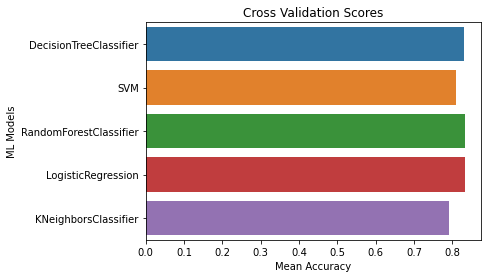

In [77]:
g = sns.barplot("Cross Validation Means", "ML Models", data = cv_results)
g.set_xlabel("Mean Accuracy")
g.set_title("Cross Validation Scores")

## Ensemble Modeling

In [78]:
votingC = VotingClassifier(estimators = [("dt",best_estimators[0]),
                                        ("rfc",best_estimators[2]),
                                        ("lr",best_estimators[3])],
                                        voting = "soft", n_jobs = -1)
votingC = votingC.fit(X_train, y_train)
print(accuracy_score(votingC.predict(X_test),y_test))

0.8116591928251121


## Prediction and Submission

In [79]:
test_survived = pd.Series(votingC.predict(test), name = "Survived").astype(int)
results = pd.concat([test_PassengerId, test_survived],axis = 1)

In [80]:
results

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [81]:
results.to_csv("titanic.csv", index = False)